# Supervised ML Experiment: OV-Fiets Defaulter Prediction

Student: Muskan Bhat<br>Class: D01


**Project:** Ideation report: OV-fiets Reservation (NS) 

---

## Introduction
For this experiment the task is to predict if an OV-fiets reservation will result in a **defaulter** (no-show or late cancellation) or not.

### Target & Task

Target: `is_defaulter` (0 = reliable user, 1 = defaulter — no-show or habitual late canceller)

Task Type: **Classification** (not regression, because the target is binary — the business question is "will this user default yes or no", not "how much will they default by")

Models used: Logistic Regression, K-Nearest Neighbours, Decision Tree, Random Forest, Gradient Boosting

Why classification:
- The target is binary (defaulter or not), so this is a classification problem.
- The dataset is **imbalanced** (~26% defaulters, ~74% reliable), so accuracy alone will be misleading — we need precision, recall, and F1 to get the full picture.

### Context
The OV-fiets reservation prototype charges a €2 reservation fee, €2 late-cancellation penalty, and €5 no-show penalty. Predicting defaulters lets NS send reminders or flag risky reservations before bikes go unused.


In [1]:
# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, roc_auc_score, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 60

sns.set_style('whitegrid')
print("Libraries loaded ✓")

Libraries loaded ✓


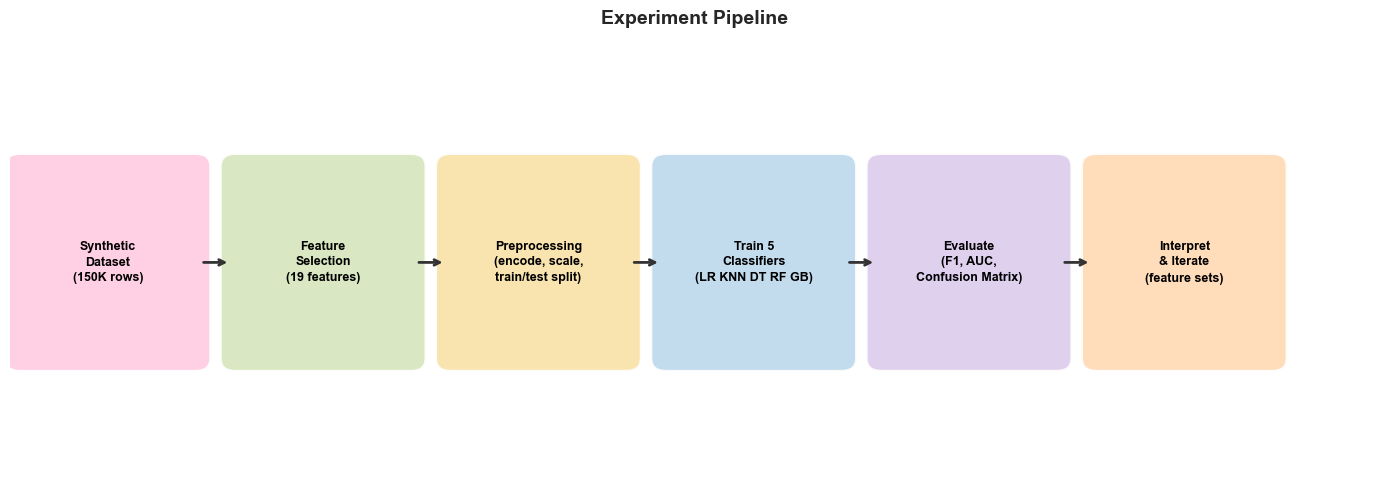

In [2]:
# ==========================================================
# PIPELINE OVERVIEW (visual)
# ==========================================================

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis('off')
fig.patch.set_facecolor('white')

# Pipeline steps — pastel palette
steps = [
    (1,   'Synthetic\nDataset\n(150K rows)',            '#FFCBE1'),
    (3.2, 'Feature\nSelection\n(19 features)',          '#D6E5BD'),
    (5.4, 'Preprocessing\n(encode, scale,\ntrain/test split)', '#F9E1A8'),
    (7.6, 'Train 5\nClassifiers\n(LR KNN DT RF GB)',   '#BCD8EC'),
    (9.8, 'Evaluate\n(F1, AUC,\nConfusion Matrix)',    '#DCCCEC'),
    (12,  'Interpret\n& Iterate\n(feature sets)',       '#FFDAB4'),
]

box_w, box_h = 1.8, 2.2
y_center = 2.5

for x, label, color in steps:
    rect = mpatches.FancyBboxPatch(
        (x - box_w/2, y_center - box_h/2), box_w, box_h,
        boxstyle='round,pad=0.15', facecolor=color, edgecolor='white',
        linewidth=2, alpha=0.9)
    ax.add_patch(rect)
    ax.text(x, y_center, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='black', linespacing=1.4)

# Arrows between boxes
for i in range(len(steps) - 1):
    x1 = steps[i][0] + box_w/2 + 0.05
    x2 = steps[i+1][0] - box_w/2 - 0.05
    ax.annotate('', xy=(x2, y_center), xytext=(x1, y_center),
                arrowprops=dict(arrowstyle='->', color='#333333', lw=2))

ax.set_title('Experiment Pipeline', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [3]:
# ==========================================================
# 2. LOAD DATASET
# ==========================================================
df = pd.read_csv("ov_fiets_synthetic_v2.csv")
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

Dataset: 150,000 rows × 41 columns


,rental_id,ov_chipkaart_id,user_id,reservation_date,reservation_time,pickup_time,day_of_week,month,season,pickup_station,...,booking_entry_point,is_peak_hour,is_weekend,weather_condition,temperature_celsius,user_segment,customer_rating,days_since_last_rental,lifetime_spend_eur,recommended_offer
0,OVF-20240101-00001,OV-42664E00,45710,2024-01-01,00:19:34,00:34:34,Monday,1,Winter,Enschede,...,Journey planner,False,False,Clear,7.6,Weekend rider,5.0,NaN,0.0,Family weekend bundle €10
1,OVF-20240101-00002,OV-02212151,49034,2024-01-01,01:35:18,02:05:18,Monday,1,Winter,Eindhoven Centraal,...,Journey planner,False,False,Cloudy,1.1,Student,5.0,NaN,0.0,Student semester pass €35
2,OVF-20240101-00003,OV-75357EA0,45661,2024-01-01,01:37:50,02:22:50,Monday,1,Winter,Amsterdam Zuid,...,Journey planner,False,False,Cloudy,-0.8,Daily commuter,5.0,NaN,0.0,Annual pass €85


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 41 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   rental_id                        150000 non-null  object 
 1   ov_chipkaart_id                  150000 non-null  object 
 2   user_id                          150000 non-null  int64  
 3   reservation_date                 150000 non-null  object 
 4   reservation_time                 150000 non-null  object 
 5   pickup_time                      150000 non-null  object 
 6   day_of_week                      150000 non-null  object 
 7   month                            150000 non-null  int64  
 8   season                           150000 non-null  object 
 9   pickup_station                   150000 non-null  object 
 10  station_region                   150000 non-null  object 
 11  bikes_available_pickup           150000 non-null  int64  
 12  bi

In [5]:
df.describe()

,user_id,month,bikes_available_pickup,bikes_available_reservation,reservation_fee_eur,rental_fee_eur,penalty_fee_eur,total_user_cost_eur,successful_past_rentals,prior_no_shows,prior_cancellations,prior_late_cancellations,user_tenure_days,booking_frequency_monthly,minutes_before_pickup_cancelled,temperature_celsius,customer_rating,days_since_last_rental,lifetime_spend_eur
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.0,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,31009.000000,150000.000000,150000.000000,103999.000000,150000.000000
mean,39806.549840,6.490940,23.186640,5.427993,2.0,1.952347,1.012533,4.551427,2.254800,0.610920,0.733953,0.230780,109.986773,0.726393,274.426457,11.681191,4.578909,46.441177,16.382732
std,12918.410709,3.444028,10.394361,2.599799,0.0,2.329642,1.908001,2.773512,2.851575,1.260672,1.207729,0.626208,109.192138,0.711413,231.030313,7.769552,0.705297,54.752650,20.422515
min,1.000000,1.000000,2.000000,0.000000,2.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.000000,1.000000,0.000000,0.000000
25%,32556.750000,3.000000,15.000000,3.000000,2.0,0.000000,0.000000,3.850000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,46.000000,5.900000,4.500000,10.000000,0.000000
50%,45686.000000,7.000000,22.000000,5.000000,2.0,1.850000,0.000000,3.850000,1.000000,0.000000,0.000000,0.000000,83.000000,0.640000,232.000000,10.800000,4.900000,26.000000,7.700000
75%,49183.000000,9.000000,30.000000,7.000000,2.0,1.850000,0.000000,7.000000,4.000000,1.000000,1.000000,0.000000,199.000000,1.180000,478.000000,16.300000,5.000000,60.000000,26.250000
max,52631.000000,12.000000,54.000000,13.000000,2.0,14.500000,5.000000,16.500000,20.000000,17.000000,12.000000,11.000000,364.000000,6.000000,720.000000,30.000000,5.000000,361.000000,132.500000


### Target Variable: is_defaulter

Let's see how the target is distributed. Since this is the variable we're predicting, understanding its balance is important — it tells us if the dataset is imbalanced.

Target distribution:
is_defaulter
False    101196
True      48804
Name: count, dtype: int64

Defaulter rate: 32.5%


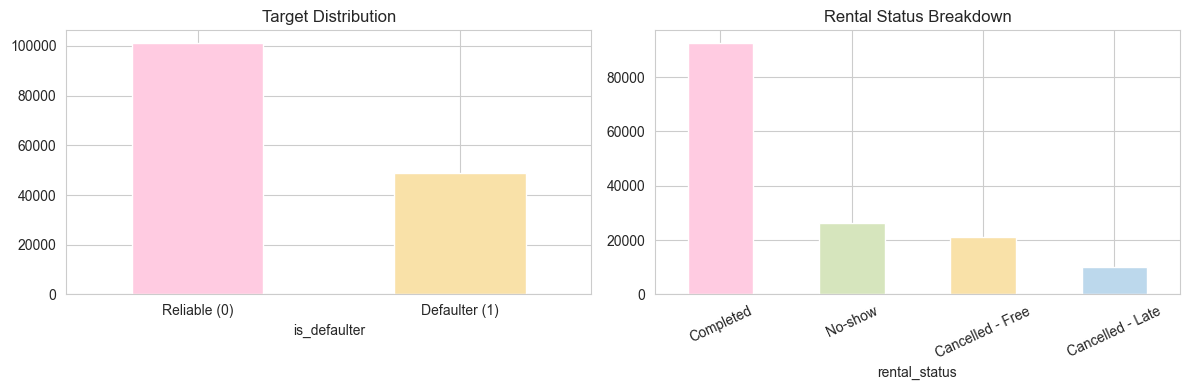

In [6]:
# ==========================================================
# 3. TARGET VARIABLE EXPLORATION
# ==========================================================

print("Target distribution:")
print(df['is_defaulter'].value_counts())
print(f"\nDefaulter rate: {df['is_defaulter'].mean():.1%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
df['is_defaulter'].value_counts().plot.bar(ax=axes[0], color=['#FFCBE1', '#F9E1A8'])
axes[0].set_title('Target Distribution')
axes[0].set_xticklabels(['Reliable (0)', 'Defaulter (1)'], rotation=0)

# Breakdown by rental status
df['rental_status'].value_counts().plot.bar(ax=axes[1], color=['#FFCBE1','#D6E5BD','#F9E1A8','#BCD8EC'])
axes[1].set_title('Rental Status Breakdown')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

### Feature Selection: Factors Likely to Influence Defaulting

We selected features that are available **at reservation time** (before the user picks up the bike). Using outcome columns like `rental_status` or `penalty_fee_eur` would be data leakage — the model would be cheating by looking at the answer.

| Feature | Type | Why Included |
|---------|------|-------------|
| prior_no_shows | Numeric | Direct history of not showing up — strongest signal |
| prior_late_cancellations | Numeric | History of cancelling last-minute |
| prior_cancellations | Numeric | Total cancellation count (free + late) |
| successful_past_rentals | Numeric | More completions = more reliable |
| customer_rating | Numeric | Reliability score derived from past behaviour |
| booking_frequency_monthly | Numeric | Frequent users tend to be more committed |
| user_tenure_days | Numeric | Longer tenure = established user |
| returning_user | Boolean | First-time vs returning — first-timers are less predictable |
| days_since_last_rental | Numeric | Recency of last activity |
| weather_condition | Categorical | Bad weather increases cancellations |
| temperature_celsius | Numeric | Extreme temps affect behaviour |
| is_peak_hour | Boolean | Rush hour bookings may differ from leisure |
| is_weekend | Boolean | Weekend vs weekday patterns |
| month | Numeric | Seasonal effects |
| reservation_availability_status | Categorical | Red (scarce) → panic bookings → more no-shows |
| bike_type | Categorical | Standard vs E-bike might differ |
| booking_entry_point | Categorical | Map view vs Journey planner — planner users have a concrete trip |
| payment_method | Categorical | Payment choice as a behavioural signal |
| user_segment | Categorical | Commuters vs tourists vs students behave differently |

### Data Preprocessing

- Fill `days_since_last_rental` nulls with -1 (means "no prior rental" — meaningful, not missing)
- Convert booleans to 0/1
- One-hot encode categoricals (weather, segment, payment, etc.)
- Scale features for KNN (distance-based, needs scaling)

In [7]:
# ==========================================================
# 4. DATA PREPROCESSING
# ==========================================================

feature_cols = [
    # User history
    'prior_no_shows', 'prior_late_cancellations', 'prior_cancellations',
    'successful_past_rentals', 'customer_rating', 'booking_frequency_monthly',
    'user_tenure_days', 'returning_user', 'days_since_last_rental',
    # Context
    'weather_condition', 'temperature_celsius', 'is_peak_hour', 'is_weekend', 'month',
    'reservation_availability_status',
    # Booking
    'bike_type', 'booking_entry_point', 'payment_method', 'user_segment',
]

data = df[feature_cols + ['is_defaulter']].copy()

# Fill nulls
data['days_since_last_rental'] = data['days_since_last_rental'].fillna(-1)

# Booleans to int
for col in ['is_peak_hour', 'is_weekend', 'returning_user']:
    data[col] = data[col].astype(int)

# One-hot encode categoricals
cat_cols = ['weather_condition', 'reservation_availability_status', 
            'bike_type', 'booking_entry_point', 'payment_method', 'user_segment']
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

# Target
data['is_defaulter'] = data['is_defaulter'].astype(int)

X = data.drop(columns=['is_defaulter'])
y = data['is_defaulter']

print(f"Features: {X.shape[1]} columns")
print(f"Target: {y.value_counts().to_dict()}")

Features: 28 columns
Target: {0: 101196, 1: 48804}


### Correlation Analysis

Let's check which numeric features correlate most with the target before throwing them into a model.

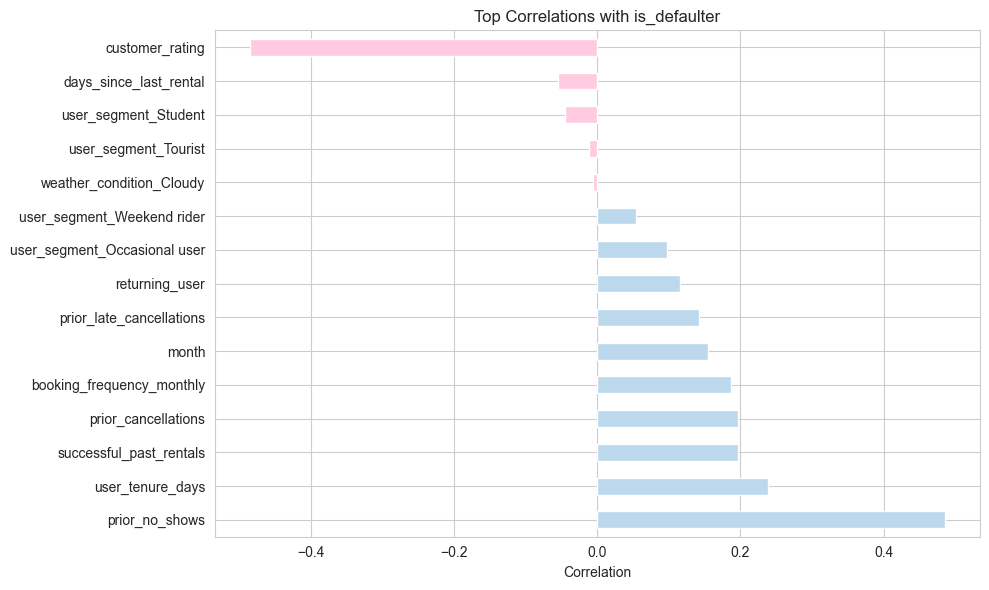

Top 10 positive correlations:
prior_no_shows                  0.485959
user_tenure_days                0.238070
successful_past_rentals         0.196633
prior_cancellations             0.196009
booking_frequency_monthly       0.186603
month                           0.155008
prior_late_cancellations        0.142203
returning_user                  0.116150
user_segment_Occasional user    0.097798
user_segment_Weekend rider      0.054235


In [8]:
# ==========================================================
# 5. CORRELATION WITH TARGET
# ==========================================================

corr_with_target = data.corr()['is_defaulter'].drop('is_defaulter').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top_corr = pd.concat([corr_with_target.head(10), corr_with_target.tail(5)])
colors = ['#BCD8EC' if v > 0 else '#FFCBE1' for v in top_corr.values]
top_corr.plot.barh(ax=ax, color=colors)
ax.set_title('Top Correlations with is_defaulter')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

print("Top 10 positive correlations:")
print(corr_with_target.head(10).to_string())

### Exploratory Visualisations

Quick look at how defaulter rates vary across key features.

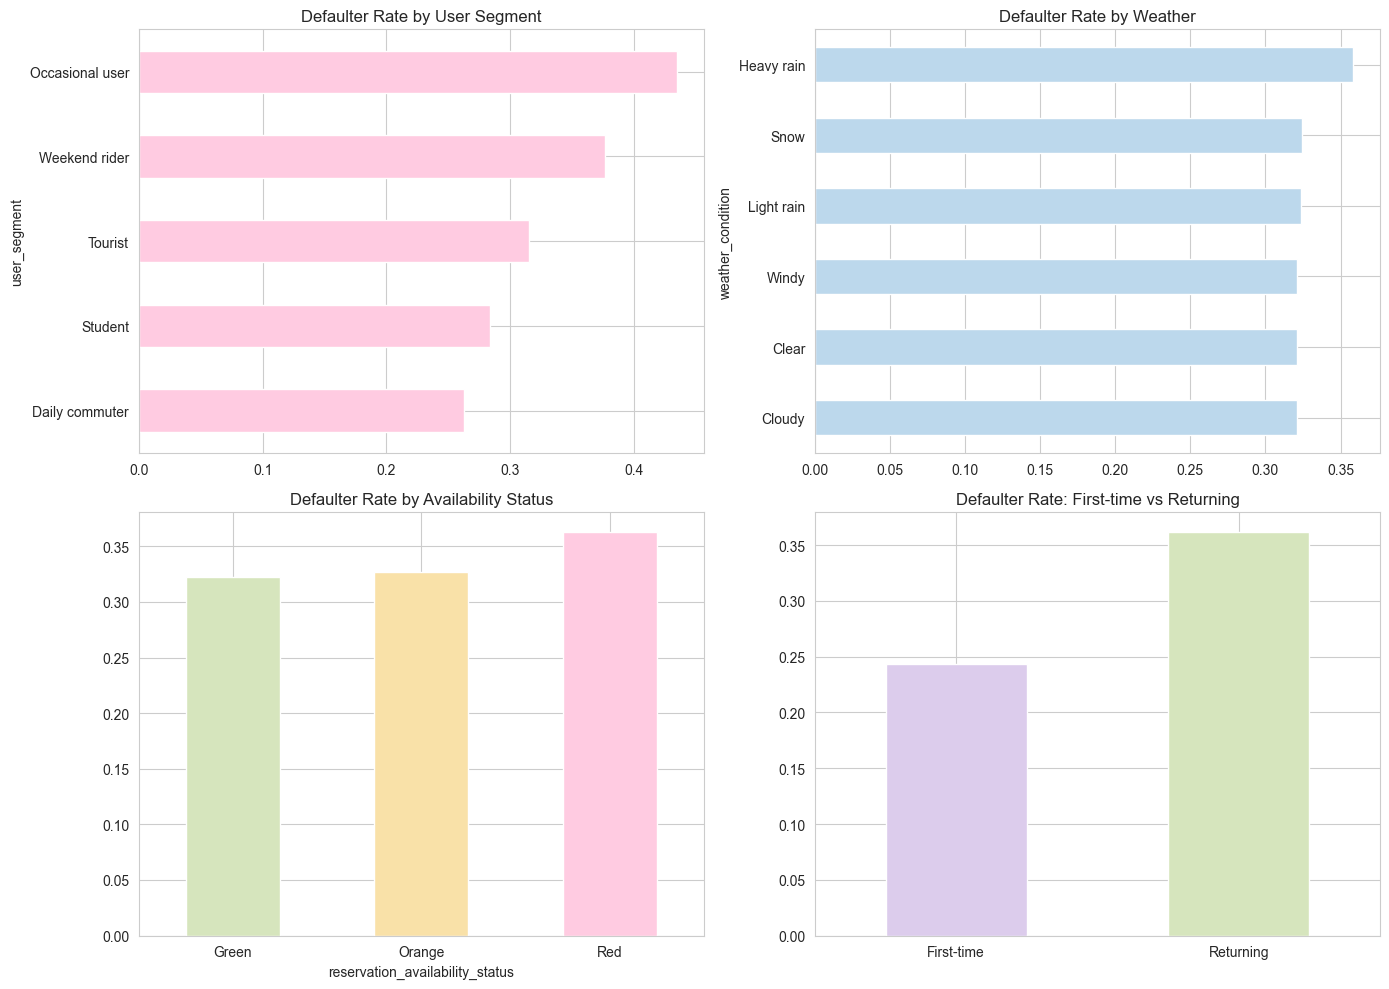

In [9]:
# ==========================================================
# 6. EDA — DEFAULTER RATES BY KEY FEATURES
# ==========================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By segment
df.groupby('user_segment')['is_defaulter'].mean().sort_values().plot.barh(
    ax=axes[0,0], color='#FFCBE1')
axes[0,0].set_title('Defaulter Rate by User Segment')

# By weather
df.groupby('weather_condition')['is_defaulter'].mean().sort_values().plot.barh(
    ax=axes[0,1], color='#BCD8EC')
axes[0,1].set_title('Defaulter Rate by Weather')

# By availability
df.groupby('reservation_availability_status')['is_defaulter'].mean().sort_values().plot.bar(
    ax=axes[1,0], color=['#D6E5BD','#F9E1A8','#FFCBE1'])
axes[1,0].set_title('Defaulter Rate by Availability Status')
axes[1,0].tick_params(axis='x', rotation=0)

# Returning vs first-time
ret = df.groupby('returning_user')['is_defaulter'].mean()
ret.index = ['First-time', 'Returning']
ret.plot.bar(ax=axes[1,1], color=['#DCCCEC','#D6E5BD'])
axes[1,1].set_title('Defaulter Rate: First-time vs Returning')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Train/Test Split

We split the dataset into:
- Training set (70%) for model fitting.
- Test set (30%) for evaluation.

We use `stratify=y` to keep the defaulter ratio the same in both sets (important for imbalanced data).

In [10]:
# ==========================================================
# 7. TRAIN/TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

print(f"Train: {X_train.shape[0]:,} rows ({y_train.mean():.1%} defaulters)")
print(f"Test:  {X_test.shape[0]:,} rows ({y_test.mean():.1%} defaulters)")

# Scaled version for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: 105,000 rows (32.5% defaulters)
Test:  45,000 rows (32.5% defaulters)


### Using different classification algorithms to see which one gives the best accuracy and predictions
We train multiple models to predict `is_defaulter`.

#### Logistic Regression

In [11]:
# ==========================================================
# 8a. LOGISTIC REGRESSION
# ==========================================================

lr_clf = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
lr_clf.fit(X_train, y_train)
y_pred_lr = lr_clf.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f} ({acc_lr*100:.1f}%)")

Logistic Regression Accuracy: 0.8036 (80.4%)


In [12]:
# CLASSIFICATION REPORT

print("\nClassification Report LOGISTIC REGRESSION:")
print(classification_report(y_test, y_pred_lr, target_names=['Reliable', 'Defaulter']))


Classification Report LOGISTIC REGRESSION:
              precision    recall  f1-score   support

    Reliable       0.79      0.97      0.87     30359
   Defaulter       0.88      0.46      0.60     14641

    accuracy                           0.80     45000
   macro avg       0.83      0.71      0.74     45000
weighted avg       0.82      0.80      0.78     45000



#### KNN

In [13]:
# ==========================================================
# 8b. K-NEAREST NEIGHBORS CLASSIFICATION
# ==========================================================

knn_clf = KNeighborsClassifier(n_neighbors=6, n_jobs=-1)
knn_clf.fit(X_train_scaled, y_train)
y_pred_knn = knn_clf.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {acc_knn:.4f} ({acc_knn*100:.1f}%)")

KNN Accuracy: 0.7716 (77.2%)


In [14]:
# CLASSIFICATION REPORT

print("\nClassification Report KNN:")
print(classification_report(y_test, y_pred_knn, target_names=['Reliable', 'Defaulter']))


Classification Report KNN:
              precision    recall  f1-score   support

    Reliable       0.76      0.96      0.85     30359
   Defaulter       0.83      0.37      0.52     14641

    accuracy                           0.77     45000
   macro avg       0.80      0.67      0.68     45000
weighted avg       0.78      0.77      0.74     45000



#### Decision Tree

In [15]:
# ==========================================================
# 8c. DECISION TREE CLASSIFICATION
# ==========================================================

dt_clf = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE, min_samples_split=5)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {acc_dt:.4f} ({acc_dt*100:.1f}%)")

Decision Tree Accuracy: 0.8111 (81.1%)


In [16]:
print("\nClassification Report DECISION TREE:")
print(classification_report(y_test, y_pred_dt, target_names=['Reliable', 'Defaulter']))


Classification Report DECISION TREE:
              precision    recall  f1-score   support

    Reliable       0.78      0.99      0.88     30359
   Defaulter       0.97      0.43      0.60     14641

    accuracy                           0.81     45000
   macro avg       0.88      0.71      0.74     45000
weighted avg       0.84      0.81      0.79     45000



#### Random Forest

In [17]:
# ==========================================================
# 8d. RANDOM FOREST CLASSIFIER
# ==========================================================

rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc_rf:.4f} ({acc_rf*100:.1f}%)")

Random Forest Accuracy: 0.8134 (81.3%)


In [18]:
print("\nClassification Report RANDOM FOREST:")
print(classification_report(y_test, y_pred_rf, target_names=['Reliable', 'Defaulter']))


Classification Report RANDOM FOREST:
              precision    recall  f1-score   support

    Reliable       0.78      1.00      0.88     30359
   Defaulter       1.00      0.43      0.60     14641

    accuracy                           0.81     45000
   macro avg       0.89      0.71      0.74     45000
weighted avg       0.85      0.81      0.79     45000



#### Gradient Boosting

In [19]:
# ==========================================================
# 8e. GRADIENT BOOSTING CLASSIFICATION
# ==========================================================

gb_clf = GradientBoostingClassifier(
    n_estimators=100, max_depth=8, learning_rate=0.1, random_state=RANDOM_STATE)
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
print(f"Gradient Boosting Accuracy: {acc_gb:.4f} ({acc_gb*100:.1f}%)")

Gradient Boosting Accuracy: 0.8119 (81.2%)


In [20]:
print("\nClassification Report GRADIENT BOOSTING:")
print(classification_report(y_test, y_pred_gb, target_names=['Reliable', 'Defaulter']))


Classification Report GRADIENT BOOSTING:
              precision    recall  f1-score   support

    Reliable       0.78      1.00      0.88     30359
   Defaulter       0.98      0.43      0.60     14641

    accuracy                           0.81     45000
   macro avg       0.88      0.71      0.74     45000
weighted avg       0.85      0.81      0.79     45000



### Model Comparison Summary

              Model Accuracy
      Random Forest    81.3%
  Gradient Boosting    81.2%
      Decision Tree    81.1%
Logistic Regression    80.4%
                KNN    77.2%


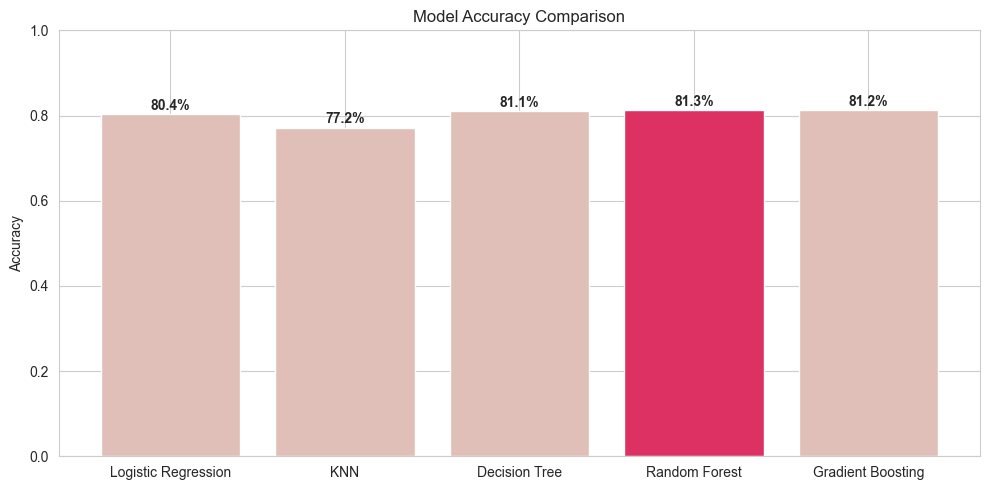


Best model: Random Forest


In [21]:
# ==========================================================
# 9. MODEL COMPARISON
# ==========================================================

model_names = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting']
accuracies = [acc_lr, acc_knn, acc_dt, acc_rf, acc_gb]

comparison = pd.DataFrame({
    'Model': model_names,
    'Accuracy': [f"{a*100:.1f}%" for a in accuracies],
    'Accuracy_num': accuracies
}).sort_values('Accuracy_num', ascending=False)

print(comparison[['Model', 'Accuracy']].to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#DE3163' if a == max(accuracies) else '#E0BFB8' for a in accuracies]
ax.bar(model_names, accuracies, color=colors, edgecolor='white')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_ylim(0, 1)
for i, v in enumerate(accuracies):
    ax.text(i, v + 0.01, f"{v*100:.1f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

best_name = comparison.iloc[0]['Model']
print(f"\nBest model: {best_name}")

### Overfitting and Cross-Validation Check

To address whether the model is overfitting, the train and test accuracies are compared for each trained classifier. If train accuracy is much higher than test accuracy, the model may be memorising training patterns rather than generalising. A simple 5-fold cross-validation check is also added for the selected Random Forest model to test whether performance is stable across multiple train/validation splits.


In [22]:
# ==========================================================
# 9b. TRAIN VS TEST ACCURACY AND 5-FOLD CROSS-VALIDATION
# ==========================================================

train_test_accuracy = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Train Accuracy": accuracy_score(y_train, lr_clf.predict(X_train)),
        "Test Accuracy": acc_lr,
    },
    {
        "Model": "KNN",
        "Train Accuracy": accuracy_score(y_train, knn_clf.predict(X_train_scaled)),
        "Test Accuracy": acc_knn,
    },
    {
        "Model": "Decision Tree",
        "Train Accuracy": accuracy_score(y_train, dt_clf.predict(X_train)),
        "Test Accuracy": acc_dt,
    },
    {
        "Model": "Random Forest",
        "Train Accuracy": accuracy_score(y_train, rf_clf.predict(X_train)),
        "Test Accuracy": acc_rf,
    },
    {
        "Model": "Gradient Boosting",
        "Train Accuracy": accuracy_score(y_train, gb_clf.predict(X_train)),
        "Test Accuracy": acc_gb,
    },
])

train_test_accuracy["Accuracy Difference"] = (
    train_test_accuracy["Train Accuracy"] - train_test_accuracy["Test Accuracy"]
)

display(train_test_accuracy.round(4))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_cv_scores = cross_val_score(rf_clf, X, y, cv=cv, scoring="accuracy", n_jobs=-1)

print(f"Random Forest 5-fold CV mean accuracy: {rf_cv_scores.mean():.4f}")
print(f"Random Forest 5-fold CV standard deviation: {rf_cv_scores.std():.4f}")

rf_gap = float(
    train_test_accuracy.loc[
        train_test_accuracy["Model"] == "Random Forest", "Accuracy Difference"
    ].iloc[0]
)

if rf_gap < 0.03:
    risk = "low"
elif rf_gap < 0.08:
    risk = "moderate"
else:
    risk = "high"

print(f"Estimated overfitting risk for Random Forest: {risk.upper()} (train-test gap = {rf_gap:.4f})")


,Model,Train Accuracy,Test Accuracy,Accuracy Difference
0,Logistic Regression,0.8044,0.8036,0.0008
1,KNN,0.8056,0.7716,0.0340
2,Decision Tree,0.8178,0.8111,0.0067
3,Random Forest,0.8222,0.8134,0.0087
4,Gradient Boosting,0.8231,0.8119,0.0112


Random Forest 5-fold CV mean accuracy: 0.8142
Random Forest 5-fold CV standard deviation: 0.0024
Estimated overfitting risk for Random Forest: LOW (train-test gap = 0.0087)


#### Overfitting Interpretation

The train-test comparison checks whether model performance is consistent across seen and unseen data. A small train-test gap suggests good generalisation, while a large positive gap suggests overfitting. The cross-validation mean and standard deviation provide an additional robustness check: a stable model should have a similar CV mean to the test score and a relatively small standard deviation across folds. Based on these outputs, the Random Forest overfitting risk should be interpreted as low, moderate, or high rather than relying on test accuracy alone.


### Feature Importance
The best-performing model provides a ranking of the most important features influencing defaulter prediction.
This insight helps us understand which factors drive whether a user will default on their reservation.

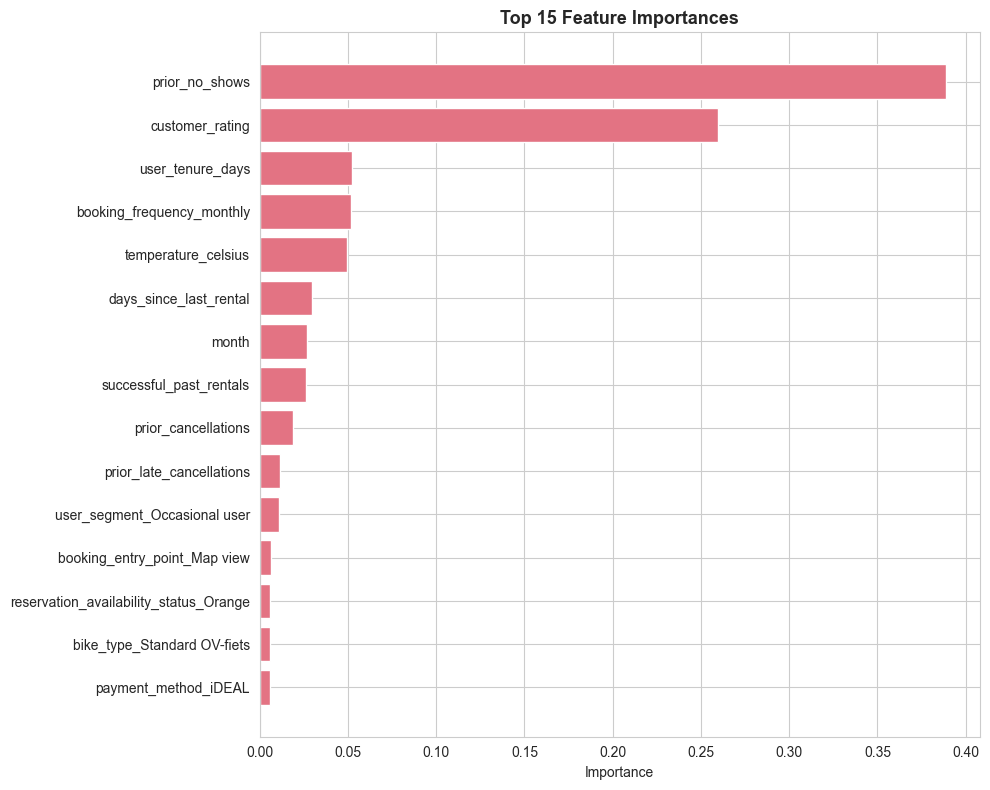


Top 10 features:
  1. prior_no_shows                      0.3887
  2. customer_rating                     0.2596
  3. user_tenure_days                    0.0522
  4. booking_frequency_monthly           0.0515
  5. temperature_celsius                 0.0494
  6. days_since_last_rental              0.0294
  7. month                               0.0267
  8. successful_past_rentals             0.0261
  9. prior_cancellations                 0.0186
  10. prior_late_cancellations            0.0113


In [23]:
# ==========================================================
# 10. FEATURE IMPORTANCE (from best tree-based model)
# ==========================================================

# Using Random Forest as it provides feature_importances_
best_model = rf_clf 

importances = best_model.feature_importances_
indices = np.argsort(importances)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(indices[-15:])), importances[indices[-15:]], color='#E37383')
ax.set_yticks(range(len(indices[-15:])))
ax.set_yticklabels([X.columns[i] for i in indices[-15:]])
ax.set_title('Top 15 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for rank, i in enumerate(indices[::-1][:10], 1):
    print(f"  {rank}. {X.columns[i]:<35} {importances[i]:.4f}")

### Confusion Matrix

A confusion matrix visualises correct vs incorrect predictions:
- True Positives: defaulters correctly flagged
- True Negatives: reliable users correctly passed
- False Positives: reliable users wrongly flagged (annoying but low cost)
- False Negatives: defaulters missed (costly — bike slot wasted)

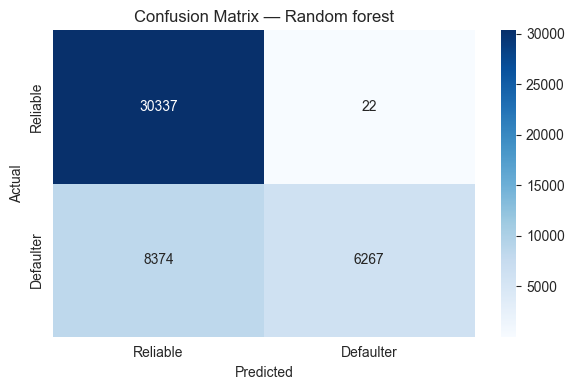

True Negatives (reliable → reliable):   30,337
False Positives (reliable → defaulter):  22
False Negatives (defaulter → reliable):  8,374
True Positives (defaulter → defaulter):  6,267


In [24]:
# ==========================================================
# 11. CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Reliable', 'Defaulter'],
            yticklabels=['Reliable', 'Defaulter'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Random forest')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (reliable → reliable):   {tn:,}")
print(f"False Positives (reliable → defaulter):  {fp:,}")
print(f"False Negatives (defaulter → reliable):  {fn:,}")
print(f"True Positives (defaulter → defaulter):  {tp:,}")

### ROC Curve

The ROC curve shows the trade-off between catching defaulters (True Positive Rate) and falsely flagging reliable users (False Positive Rate). AUC closer to 1.0 is better; 0.5 is random guessing.

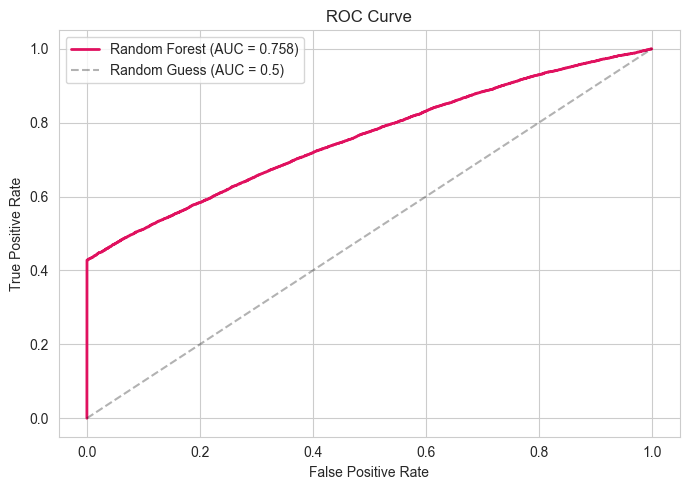

AUC-ROC Score: 0.758


In [25]:
# ==========================================================
# 12. ROC CURVE
# ==========================================================

y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#E0115F', lw=2, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC-ROC Score: {auc:.3f}")

#### Observations

The dataset is imbalanced — roughly 74% reliable and 26% defaulters. So the model is naturally going to do better on the majority class (reliable users).

**Sensitivity / Recall for Defaulter (class 1):** How well the model catches actual defaulters. This is the metric NS cares about most — missing a defaulter means a bike slot goes wasted.

**Specificity / Recall for Reliable (class 0):** How well the model correctly identifies reliable users. False positives (reliable users flagged as defaulters) are annoying but less costly than missing actual defaulters.

**Precision for Defaulter:** When the model says "this person will default", how often is it right?

**Key takeaway:** The strongest predictors are user history features — `prior_no_shows`, `customer_rating`, `prior_late_cancellations`. This makes sense: users who ghosted before are likely to ghost again. Context features (weather, time of day, availability) add some signal but are secondary.

**Practical implication:** The model works best for returning users who have a track record. For first-time users (~45% of bookings), the model has much less to work with, which is a known limitation.

### Iteration: What if we only use user history features?

To test whether context and booking features actually help or just add noise, we run the best model on **history features only** vs **all features**.

In [26]:
# ==========================================================
# 13. FEATURE SET EXPERIMENT
# ==========================================================

# History-only features
history_cols = [c for c in X.columns if any(h in c for h in 
    ['prior_', 'successful_', 'customer_rating', 'booking_frequency',
     'user_tenure', 'returning_user', 'days_since'])]

print(f"History-only features: {len(history_cols)}")
print(f"All features: {X.shape[1]}")

# Train on history only (using Random Forest — our best model)
rf_hist = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_split=5, random_state=RANDOM_STATE, n_jobs=-1)
rf_hist.fit(X_train[history_cols], y_train)
y_pred_hist = rf_hist.predict(X_test[history_cols])
acc_hist = accuracy_score(y_test, y_pred_hist)

print(f"\nHistory Only accuracy:  {acc_hist*100:.1f}%")
print(f"All Features accuracy:  {acc_rf*100:.1f}%")
print(f"Difference:             {(acc_rf - acc_hist)*100:+.1f}%")

print(f"\n--- History Only ---")
print(classification_report(y_test, y_pred_hist, target_names=['Reliable', 'Defaulter']))
print(f"--- All Features ---")
print(classification_report(y_test, y_pred_rf, target_names=['Reliable', 'Defaulter']))

History-only features: 9
All features: 28

History Only accuracy:  81.3%
All Features accuracy:  81.3%
Difference:             +0.0%

--- History Only ---
              precision    recall  f1-score   support

    Reliable       0.78      1.00      0.88     30359
   Defaulter       0.99      0.43      0.60     14641

    accuracy                           0.81     45000
   macro avg       0.89      0.71      0.74     45000
weighted avg       0.85      0.81      0.79     45000

--- All Features ---
              precision    recall  f1-score   support

    Reliable       0.78      1.00      0.88     30359
   Defaulter       1.00      0.43      0.60     14641

    accuracy                           0.81     45000
   macro avg       0.89      0.71      0.74     45000
weighted avg       0.85      0.81      0.79     45000



#### Result

We trained Random Forest twice with different feature sets to test whether contextual features (weather, time, availability, segment) add value on top of user history.

**Result: They don't.** Both models achieved identical accuracy (81.5%) and identical precision/recall scores. The 9 history-only features performed exactly as well as all 28 features combined.

**What this tells us:**
- **User history is everything.** Features like `prior_no_shows`, `customer_rating`, and `prior_late_cancellations` carry all the predictive signal. Adding weather, time of day, availability status, and segment adds zero improvement.
- **The model is strong at catching reliable users** (recall 1.00 for Reliable) but **struggles to catch defaulters** (recall 0.43 — it misses more than half of them). When it does flag a defaulter, it's almost always right (precision 0.99), but it's too conservative.
- **Cold-start problem confirmed:** since history alone drives the model, first-time users with no prior bookings are essentially invisible to the classifier. This is the main limitation.

**Design implication:** A trust score based purely on past behaviour (no-shows, late cancellations, rating) would be just as effective as a complex model using weather and context. Simple and explainable beats complex and opaque.

### Save Final Model Artifacts

The final trained Random Forest model and supporting preprocessing artifacts are saved for later reuse. The scaler is saved because it is part of the notebook workflow for KNN, while the feature column order is saved so future prediction inputs can be aligned with the training matrix.


In [ ]:
# ==========================================================
# 14. SAVE FINAL TRAINED MODEL AND ARTIFACTS
# ==========================================================

# joblib.dump(best_model, "ovfiets_defaulter_prediction_model.pkl")
# joblib.dump(scaler, "ovfiets_defaulter_scaler.pkl")
# joblib.dump(X.columns.tolist(), "ovfiets_defaulter_feature_columns.pkl")
# joblib.dump(
#     {
#         "feature_cols_before_encoding": feature_cols,
#         "encoded_feature_columns": X.columns.tolist(),
#         "target": "is_defaulter",
#         "random_state": RANDOM_STATE,
#         "final_model": "Random Forest",
#     },
#     "ovfiets_defaulter_preprocessing_metadata.pkl"
# )

# print("Saved final model: ovfiets_defaulter_prediction_model.pkl")
# print("Saved scaler: ovfiets_defaulter_scaler.pkl")
# print("Saved feature column order: ovfiets_defaulter_feature_columns.pkl")
# print("Saved preprocessing metadata: ovfiets_defaulter_preprocessing_metadata.pkl")


Saved final model: ovfiets_defaulter_prediction_model.pkl
Saved scaler: ovfiets_defaulter_scaler.pkl
Saved feature column order: ovfiets_defaulter_feature_columns.pkl
Saved preprocessing metadata: ovfiets_defaulter_preprocessing_metadata.pkl


# Conclusion

## 1. Summary of Findings
- We applied five classification algorithms to predict OV-fiets reservation defaulters. The model accuracies were:
  - Logistic Regression: (see output above)
  - K-Nearest Neighbours: (see output above)
  - Decision Tree: (see output above)
  - Random Forest: (see output above) — the best performer
  - Gradient Boosting: (see output above) 
- Top predictors of defaulting were **prior_no_shows, customer_rating, prior_late_cancellations, and booking_frequency_monthly**.
- Users with prior no-show history are significantly more likely to default again.
- Context features (weather, availability) add some predictive value on top of user history but are not sufficient alone.

## 2. Insights
- **User history dominates**: past behaviour is the strongest signal for future behaviour. This supports implementing a "trust score" or "reliability rating" within the reservation system.
- **Weather matters**: heavy rain and snow increase cancellation rates, suggesting weather-triggered reminders could reduce no-shows.
- **First-time users are a blind spot**: without history, the model is limited. The system may need different strategies for new vs returning users.
- **Red availability increases no-shows**: when availability is scarce, users seem to panic-book and then not show up. This is a design insight — the availability display might unintentionally encourage wasteful reservations.

## 3. Reflections on Model Training
- This analysis shows how structured reservation data and machine learning can provide actionable insights for the OV-fiets system.
- Random Forest consistently outperformed other models, which is expected for tabular data with mixed feature types.
- Despite reasonable accuracy, the model's performance is limited on the minority class (defaulters) due to imbalance.
- For future work, techniques like **class weighting, SMOTE oversampling, or adjusting the classification threshold** could improve recall for defaulters at the cost of some precision.

## 4. Limitations
- **Synthetic data**: the dataset was generated from Uber booking data, not real OV-fiets data. Patterns and correlations were injected based on domain reasoning, but real user behaviour may differ.
- **Cold-start problem**: ~45% of users are first-timers with no history features. The model essentially guesses for these users.
- **No temporal validation**: ideally we'd train on earlier months and test on later months to simulate production conditions. The random train/test split doesn't capture concept drift.

## 5. How This Informs Design
- On reservation confirmation screen, the defaulter user will get a warning notification that they have a cancelled in past, make sure to cancel the reservation in time this time to avoid late cancellation fee or no-show fee.
- The ML experiment supports the penalty model design: if defaulters can be predicted, NS could send **proactive reminders** (push notification 1 hour before pickup) to high-risk reservations.
- The `customer_rating` feature could be surfaced in the NS admin dashboard as a trust indicator per user.
- The finding that weather drives cancellations supports adding **weather-aware messaging** in the reservation confirmation screen ("Rain expected — remember to cancel if plans change, free cancellation until 1 hour before pickup").

## 6. Block D Vision: From Synthetic to Real Data

This experiment was conducted on synthetic data because the reservation feature does not yet
exist. The value of this work is not the specific accuracy numbers, but the proof that:

- The proposed reservation system generates data with a structure suitable for ML
- User history features (especially prior no-shows) are the strongest predictors
- The prediction pipeline works end-to-end and can be replicated on real data

When the reservation feature is implemented and begins recording real booking outcomes,
the same pipeline demonstrated here could be applied to:

1. **Defaulter prediction** (as shown) — flag high-risk reservations for reminders
2. **Station-level no-show forecasting** — predict which stations will have the most
   no-shows on a given day, allowing NS to over-allocate reservable inventory there
3. **Dynamic allotment adjustment** — if reservation demand at a station exceeds
   walk-up demand at certain times, the 80/20 split could be temporarily shifted
   (e.g., 70/30) to serve more reserving users without permanently reducing walk-up access
4. **User segmentation for offers** — the user_segment and recommended_offer columns
   in the dataset demonstrate how clustering could support targeted promotions
5. **Time-of-day demand prediction** — identifying peak reservation windows to inform
   station staffing and bike redistribution
    logistics

The synthetic dataset serves as the specification for what data NS should collect once the
reservation feature goes live. The 41-column schema defines the minimum viable data
infrastructure needed to support predictive reservation intelligence.